# TD7

#  Proposer une simulation pour les loi suivantes:


1. Loi de Cauchy, de densité

$$x \mapsto \frac{1}{\pi} \frac{1}{1 + x^2}.$$


2. Loi définie par

$$\forall n \in \mathbb{N}^*, \; \mathbb{P}(X = n) = \frac{6}{\pi^2} \frac{1}{n^2}.$$


3. Loi uniforme sur

$$\{(x, y) \in \mathbb{R}^2, \; x \geq 1, \; y \geq 0 \text{ et } x^2 y \leq 1\}.$$

4. Utiliser la première méthode du rejet pour simuler une loi uniforme sur la boule de centre  O  et de rayon  1  dans $ \mathbb{R}^3 $.

5. On veut simuler une loi du $ \chi^2 $ à 3 degrés de liberté par la méthode du rejet, en s’appuyant sur une loi exponentielle de paramètre $ \lambda $. Quel est le meilleur choix de $ \lambda $ (celui qui provoquera, en moyenne, le moins de rejets) ?

6. Mettre en place une méthode du rejet et une méthode de la fonction inverse pour simuler une loi normale centrée réduite.


#  Mini-Projet : Simulation Monte Carlo d'un système de file d'attente M/M/1

## Objectif du projet:

  Estimer par simulation Monte Carlo le temps d'attente moyen des clients dans un système de file d'attente M/M/1, et comparer la précision et l'efficacité de deux méthodes de génération de nombres aléatoires exponentiels (méthode de la transformation inverse vs méthode du rejet).

## File M/M/1 :

1. (顾客到达间隔) Les intervalles entre les arrivées des clients suivent une loi exponentielle de paramètre $\lambda$ (taux d'arrivée moyen $\lambda$).
2. (服务时间) Les durées de service suivent une loi exponentielle de paramètre $\mu$ (taux de service moyen $\mu$), indépendantes des arrivées.
3. (单个服务台，先到先服务) Un seul serveur, service premier arrivé premier servi, capacité du système illimitée.
4. （平均等待时间（从到达至开始服务）的理论值) Lorsque $\lambda < \mu$, le système est stable et le temps d'attente moyen (du moment de l'arrivée au début du service) est donné par la formule théorique :
$$
W_q = \frac{\lambda}{\mu(\mu - \lambda)}.
$$


## Tâche 1 : Calcul théorique et choix des paramètres

1. Choisir les paramètres $\lambda = 0.8$ et $\mu = 1.0$. Calculer le temps d'attente moyen théorique $W_q$.

2. Expliquer pourquoi il est nécessaire d'avoir $\lambda < \mu$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Tache 1: parametres et valeur theorique
lam = 0.8
mu = 1.0

if lam >= mu:
    raise ValueError("Le systeme M/M/1 est stable seulement si lam < mu.")

Wq_theory = lam / (mu * (mu - lam))
print(f"Parametres: lambda={lam}, mu={mu}")
print(f"Temps d'attente moyen theorique Wq = {Wq_theory:.6f}")
print("Condition de stabilite: lambda < mu, sinon la file diverge.")


Parametres: lambda=0.8, mu=1.0
Temps d'attente moyen theorique Wq = 4.000000
Condition de stabilite: lambda < mu, sinon la file diverge.


## Tâche 2 : Implémentation de générateurs de nombres aléatoires exponentiels (deux méthodes)
1. Méthode A : Transformation inverse （Définir la fonction gen_exp_inverse(lam, n)）
2. Méthode B : Méthode du rejet (Acceptation-Rejet)} (Définir la fonction gen_exp_rejection(lam, n))

Vérifier la validité des générateurs (générer un grand nombre d'échantillons, tracer un histogramme et le comparer à la densité théorique)

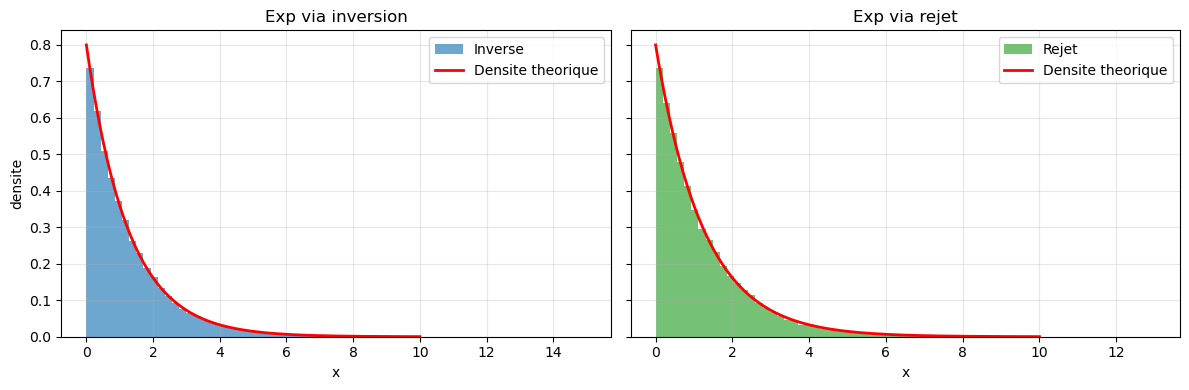

In [2]:
# Tache 2: generateurs exponentiels

def gen_exp_inverse(lam, n, rng=None):
    """Inverse transform sampling for Exp(lam)."""
    if lam <= 0:
        raise ValueError("lam must be > 0")
    rng = np.random.default_rng() if rng is None else rng
    u = rng.random(n)
    return -np.log(1.0 - u) / lam


def gen_exp_rejection(lam, n, rng=None):
    """Acceptance-rejection for Exp(lam) using proposal Exp(beta) with beta=lam/2."""
    if lam <= 0:
        raise ValueError("lam must be > 0")
    rng = np.random.default_rng() if rng is None else rng

    beta = lam / 2.0
    c = lam / beta  # =2

    out = np.empty(n)
    filled = 0
    trials = 0

    while filled < n:
        m = max(1024, 2 * (n - filled))
        y = -np.log(1.0 - rng.random(m)) / beta  # proposal Exp(beta)
        u = rng.random(m)
        accept_prob = np.exp(-(lam - beta) * y)  # f/(c g)
        keep = u <= accept_prob
        k = min(np.sum(keep), n - filled)
        if k > 0:
            out[filled:filled + k] = y[keep][:k]
            filled += k
        trials += m

    return out


# Validation visuelle des deux generateurs
n_check = 50000
rng = np.random.default_rng(42)
s1 = gen_exp_inverse(lam, n_check, rng)
s2 = gen_exp_rejection(lam, n_check, rng)

x = np.linspace(0, 10, 400)
pdf = lam * np.exp(-lam * x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(s1, bins=70, density=True, alpha=0.65, label='Inverse')
axes[0].plot(x, pdf, 'r', lw=2, label='Densite theorique')
axes[0].set_title('Exp via inversion')
axes[0].legend()

axes[1].hist(s2, bins=70, density=True, alpha=0.65, label='Rejet', color='tab:green')
axes[1].plot(x, pdf, 'r', lw=2, label='Densite theorique')
axes[1].set_title('Exp via rejet')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('x')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('densite')
plt.tight_layout()
plt.show()


## Tâche 3 : Simulation unique d'une file M/M/1

Écrire une fonction mm1\_simulation(lam, mu, n\_customers, sampler) :

1. Entrées : taux d'arrivée $\lambda$, taux de service $\mu$, nombre de clients $n_{\text{customers}}$, fonction générateur de nombres aléatoires sampler (par exemple gen\_exp\_inverse ou gen\_exp\_rejection).

2. Déroulement de la simulation :

    2.1 Générer $n_{\text{customers}}$ intervalles entre arrivées 'inter\_arrivals' et $n_{\text{customers}}$ durées de service 'services'.
    
    2.2 Initialiser 'arrival' = 0.0, 'departure = 0.0', 'total\_wait = 0.0'.
    
    2.3 Pour chaque client $i$ :
      
       (1) 'arrival' += inter\_arrivals[i]
       (2) 'start' = max(arrival, departure)
       (3) 'wait' = start - arrival
       (4) 'total\_wait' += wait
       (5) 'departure' = start + services[i]
    
    2.4 Retourner le temps d'attente moyen : 'total\_wait / n\_customers'.

Écrire le code et le tester (par exemple, $n = 10000$, afficher la valeur estimée.

In [3]:
# Tache 3: simulation unique M/M/1

def mm1_simulation(lam, mu, n_customers, sampler, rng=None):
    if not (lam > 0 and mu > 0):
        raise ValueError("lam and mu must be > 0")
    if n_customers <= 0:
        raise ValueError("n_customers must be > 0")

    inter_arrivals = sampler(lam, n_customers, rng)
    services = sampler(mu, n_customers, rng)

    arrival = 0.0
    departure = 0.0
    total_wait = 0.0

    for i in range(n_customers):
        arrival += inter_arrivals[i]
        start = max(arrival, departure)
        wait = start - arrival
        total_wait += wait
        departure = start + services[i]

    return total_wait / n_customers


rng = np.random.default_rng(123)
n_customers = 10000
w_inv = mm1_simulation(lam, mu, n_customers, gen_exp_inverse, rng)
w_rej = mm1_simulation(lam, mu, n_customers, gen_exp_rejection, rng)

print(f"Wq theorique = {Wq_theory:.6f}")
print(f"Wq simule (inverse) = {w_inv:.6f}")
print(f"Wq simule (rejet)   = {w_rej:.6f}")


Wq theorique = 4.000000
Wq simule (inverse) = 4.738403
Wq simule (rejet)   = 3.702781


## Tâche 4 : Analyse de la convergence

Discuter : lorsque $n$ augmente, l'estimation se rapproche-t-elle de la valeur théorique ? Comment évolue la fluctuation ?

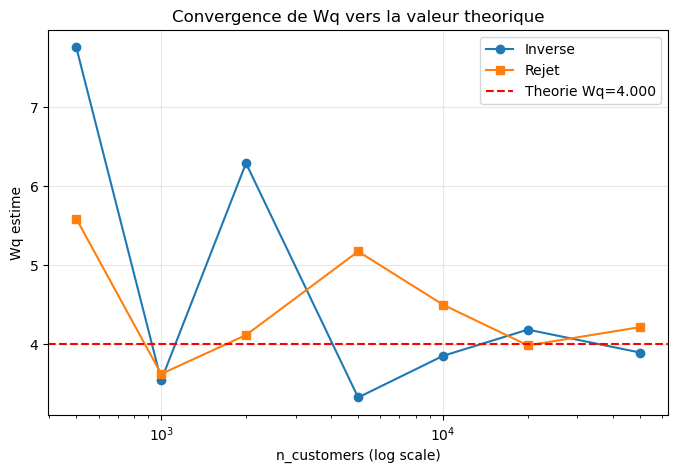

In [4]:
# Tache 4: convergence avec n croissant (une simulation par n)

n_values = [500, 1000, 2000, 5000, 10000, 20000, 50000]
rng = np.random.default_rng(2026)

conv_inv = [mm1_simulation(lam, mu, n, gen_exp_inverse, rng) for n in n_values]
conv_rej = [mm1_simulation(lam, mu, n, gen_exp_rejection, rng) for n in n_values]

plt.figure(figsize=(8, 5))
plt.plot(n_values, conv_inv, 'o-', label='Inverse')
plt.plot(n_values, conv_rej, 's-', label='Rejet')
plt.axhline(Wq_theory, color='red', linestyle='--', label=f'Theorie Wq={Wq_theory:.3f}')
plt.xscale('log')
plt.xlabel('n_customers (log scale)')
plt.ylabel('Wq estime')
plt.title('Convergence de Wq vers la valeur theorique')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Tâche 5 : Expériences répétées et estimation de la variance

Étant donné que la variabilité d'une simulation unique est grande, pour chaque $n$, on répète la simulation $R = 30$ fois, puis on calcule l'estimation moyenne et l'écart type.


1. Pour chaque $n$, exécuter 30 simulations indépendantes (à chaque fois, les nombres aléatoires sont générés à nouveau) et enregistrer les 30 temps d'attente moyens.

2. Calculer la moyenne $\bar{W}$ et l'écart type $\sigma_W$ de ces 30 valeurs.

3. Tracer la courbe de convergence avec des barres d'erreur (axe horizontal : $n$, axe vertical : $\bar{W} \pm \sigma_W$) ; représenter les deux méthodes sur le même graphique.


 Discuter si la précision des estimations est la même pour les deux méthodes, et comment l'écart type évolue lorsque $n$ augmente.


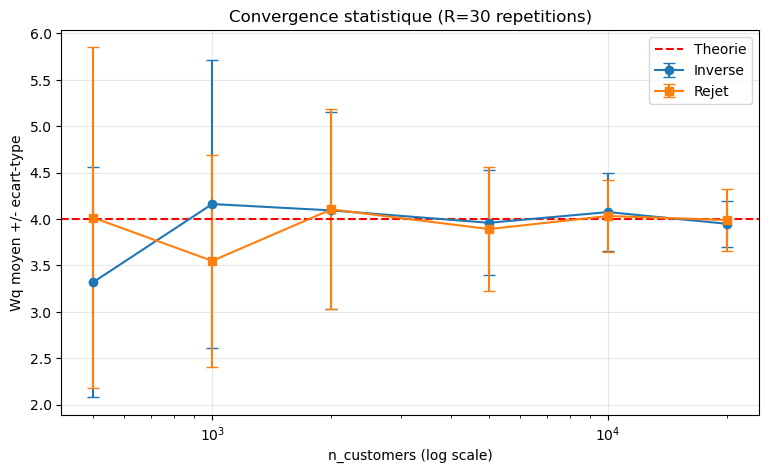

n	Inverse(mean,std)	Rejet(mean,std)
500	(3.3182, 1.2412)	(4.0139, 1.8332)
1000	(4.1607, 1.5498)	(3.5485, 1.1383)
2000	(4.0921, 1.0628)	(4.1031, 1.0762)
5000	(3.9588, 0.5652)	(3.8910, 0.6716)
10000	(4.0741, 0.4192)	(4.0319, 0.3828)
20000	(3.9477, 0.2496)	(3.9883, 0.3356)


In [5]:
# Tache 5: repetitions (R=30), moyenne et ecart-type

R = 30
n_values = [500, 1000, 2000, 5000, 10000, 20000]
rng = np.random.default_rng(7)

mean_inv, std_inv = [], []
mean_rej, std_rej = [], []

for n in n_values:
    vals_inv = np.array([mm1_simulation(lam, mu, n, gen_exp_inverse, rng) for _ in range(R)])
    vals_rej = np.array([mm1_simulation(lam, mu, n, gen_exp_rejection, rng) for _ in range(R)])

    mean_inv.append(vals_inv.mean())
    std_inv.append(vals_inv.std(ddof=1))
    mean_rej.append(vals_rej.mean())
    std_rej.append(vals_rej.std(ddof=1))

plt.figure(figsize=(9, 5))
plt.errorbar(n_values, mean_inv, yerr=std_inv, fmt='o-', capsize=4, label='Inverse')
plt.errorbar(n_values, mean_rej, yerr=std_rej, fmt='s-', capsize=4, label='Rejet')
plt.axhline(Wq_theory, color='red', linestyle='--', label='Theorie')
plt.xscale('log')
plt.xlabel('n_customers (log scale)')
plt.ylabel('Wq moyen +/- ecart-type')
plt.title('Convergence statistique (R=30 repetitions)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print('n	Inverse(mean,std)	Rejet(mean,std)')
for n, mi, si, mr, sr in zip(n_values, mean_inv, std_inv, mean_rej, std_rej):
    print(f"{n}	({mi:.4f}, {si:.4f})	({mr:.4f}, {sr:.4f})")


## Tâche 6 : Comparaison d'efficacité

1.  Enregistrer, pour chaque méthode dans la tâche 5, le temps d'exécution total pour le plus grand $n$ (ou le temps d'exécution moyen pour chaque $n$).

2.  Tracer la courbe du temps de calcul en fonction de $n$ pour les deux méthodes.

3.  Expliquer pourquoi la méthode de la transformation inverse est généralement plus rapide.

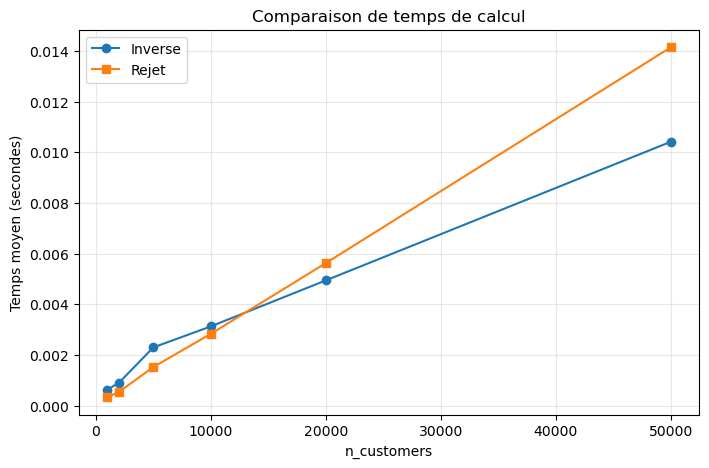

n	Inverse(s)	Rejet(s)
1000	0.000630	0.000332
2000	0.000897	0.000538
5000	0.002298	0.001524
10000	0.003128	0.002835
20000	0.004945	0.005629
50000	0.010420	0.014149


In [6]:
# Tache 6: comparaison d'efficacite (temps CPU)

n_values = [1000, 2000, 5000, 10000, 20000, 50000]
rng = np.random.default_rng(77)


def timed_run(method, n, repeats=5):
    t0 = time.perf_counter()
    for _ in range(repeats):
        _ = mm1_simulation(lam, mu, n, method, rng)
    t1 = time.perf_counter()
    return (t1 - t0) / repeats


time_inv = [timed_run(gen_exp_inverse, n) for n in n_values]
time_rej = [timed_run(gen_exp_rejection, n) for n in n_values]

plt.figure(figsize=(8, 5))
plt.plot(n_values, time_inv, 'o-', label='Inverse')
plt.plot(n_values, time_rej, 's-', label='Rejet')
plt.xlabel('n_customers')
plt.ylabel('Temps moyen (secondes)')
plt.title('Comparaison de temps de calcul')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print('n	Inverse(s)	Rejet(s)')
for n, ti, tr in zip(n_values, time_inv, time_rej):
    print(f"{n}	{ti:.6f}	{tr:.6f}")
